# Weekly project part 1
Using the image "appletree.jpg"
1) Can you segment the apples from the tree?
2) Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)
3) Can you change the color of one of them?
4) Can you segment the leaves?
    

In [30]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

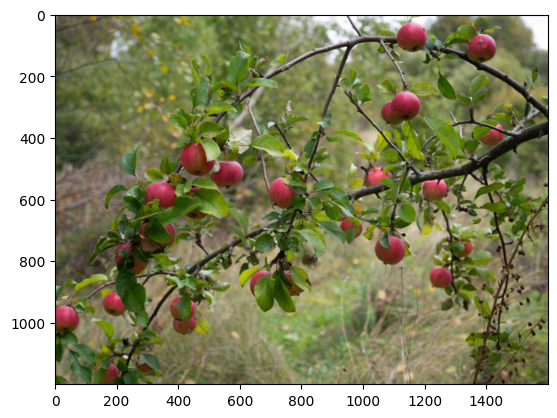

In [31]:
img = cv2.imread('appletree.jpg')
b,g,r = cv2.split(img)
image = cv2.merge([r,g,b])

plt.imshow(image)

For the filtering of the apples, we decided to use HSV colors, by applying specific upper and low limits to keep the reddish shades. We created 2 masks which we applied. Then, to delete the small holes created after the filtering process, we applied erosion with "cv2.erode" and then for the image to return to its initial size, we applied dilation with "cv2.dilate". 

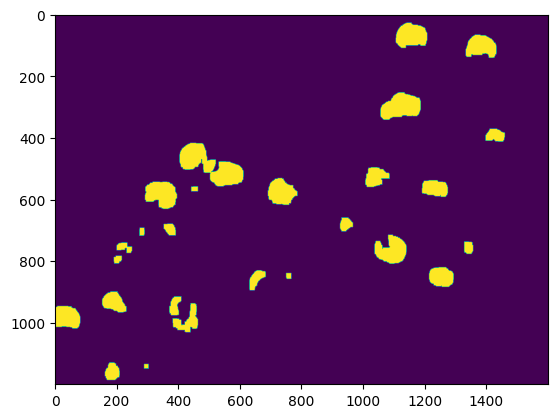

In [32]:
#Task 1 and 2

hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

lower_red1 = np.array([0, 100, 50])
upper_red1 = np.array([12, 255, 255])
lower_red2 = np.array([150, 100, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask_raw = cv2.bitwise_or(mask1, mask2)

mask = cv2.erode(mask_raw, None, iterations=4) 
mask = cv2.dilate(mask, None, iterations=7)
plt.imshow(mask)


The next step is to draw contours by using "cv2.drawContours" in order to count the separate apples created.

Found 26 apples


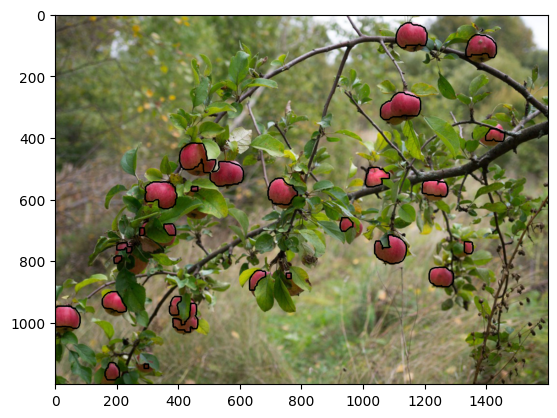

In [33]:
#Task 1 
cnts = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

output = image.copy()
for c in cnts:
    cv2.drawContours(output, [c], -1, (0, 0, 0), 3)
    
plt.imshow(output)
original_cnt_count = len(cnts)
print(f"Found {original_cnt_count} apples") #Task 2 result


# Task 2, redo

Now we want to expirement with closing small gaps where two contours belong to the same apple, as we see there are some examples of contours that are from the same apple.

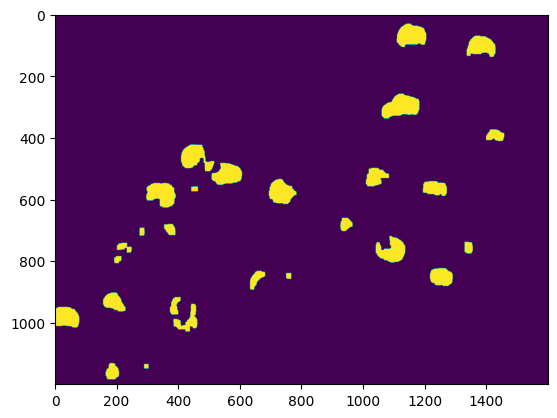

In [34]:
cnts = cv2.findContours(
    mask.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
cnts = imutils.grab_contours(cnts)

new_mask = np.zeros_like(mask_raw)

for c in cnts:

    area = cv2.contourArea(c)

    # Draw this contour into its own mask
    contour_mask = np.zeros_like(mask)
    cv2.drawContours(contour_mask, [c], -1, 255, -1)

    # Erosion strength based on contour size
    erosion_size = int(np.sqrt(area) * 0.05)

    # Make sure kernel size is odd
    kernel_size = 2 * erosion_size + 1

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (kernel_size, kernel_size)
    )

    # Erode
    contour_mask = cv2.erode(contour_mask, kernel)

    # Add it back
    new_mask[contour_mask > 0] = 255
    plt.imshow(new_mask)


Notice some of the bigger apples where falsely connected before, these are now correct

N:0, area:196.0
N:1, area:1726.5
N:2, area:4429.5
N:3, area:2748.5
N:4, area:1246.5
N:5, area:2961.5
N:6, area:283.0
N:7, area:1527.0
N:8, area:3499.0
N:9, area:426.5
N:10, area:857.0
N:11, area:884.0
N:12, area:5053.0
N:13, area:382.5
N:14, area:1006.5
N:15, area:1244.0
N:16, area:309.5
N:17, area:5547.5
N:18, area:2964.0
N:19, area:4944.0
N:20, area:2953.0
N:21, area:4966.5
N:22, area:5266.5
N:23, area:1667.5
N:24, area:6726.5
N:25, area:4656.5
N:26, area:5446.0


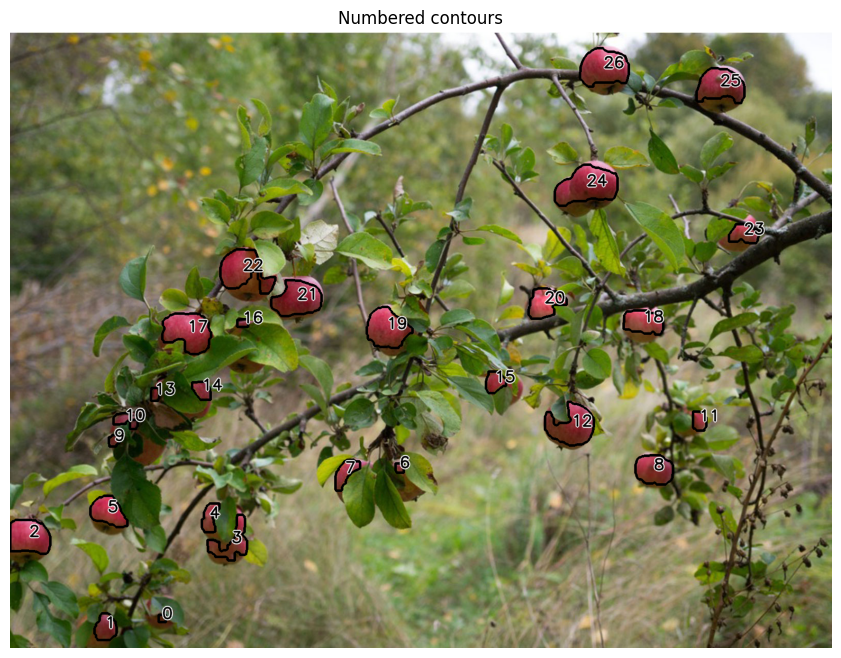

In [35]:
output = image.copy()

#Redo this with new mask
cnts_newmask = cv2.findContours(
    new_mask.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
cnts = imutils.grab_contours(cnts_newmask)


for i, c in enumerate(cnts):
    print(f"N:{i}, area:{cv2.contourArea(c)}")
    # Draw contour
    cv2.drawContours(
        output,
        [c],
        -1,
        (0, 0, 0),
        3
    )

    # Find center of contour
    M = cv2.moments(c)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        # Fallback for very small/degenerate contours
        x, y, w, h = cv2.boundingRect(c)
        cx = x + w // 2
        cy = y + h // 2

    # Write contour number
    cv2.putText(
        output,
        str(i),
        (cx, cy),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        5,
        cv2.LINE_AA
    )

    cv2.putText(
        output,
        str(i),
        (cx, cy),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 0),
        2,
        cv2.LINE_AA
    )


plt.figure(figsize=(12, 8))
plt.imshow(output)
plt.title("Numbered contours")
plt.axis("off")
plt.show()

In [36]:
def contour_distance(c1, c2):
    """Approximate minimum distance between two contours."""
    points1 = c1.reshape(-1, 2)
    points2 = c2.reshape(-1, 2)

    distances = np.linalg.norm(
        points1[:, None, :] - points2[None, :, :],
        axis=2
    )

    return np.min(distances)

In [37]:
SMALL_AREA = 1500
MAX_DISTANCE = 100
apple_mask_2 = new_mask.copy()

for i, c1 in enumerate(cnts):

    area1 = cv2.contourArea(c1)

    # Only consider small contours
    if area1 >= SMALL_AREA:
        continue

    closest_distance = float("inf")
    closest_contour = None
    closest_index = None

    # Look through ALL other small contours
    for j, c2 in enumerate(cnts):

        if i == j:
            continue

        area2 = cv2.contourArea(c2)

        if area2 >= SMALL_AREA:
            continue

        distance = contour_distance(c1, c2)

        # Keep the closest one
        if distance < closest_distance:
            closest_distance = distance
            closest_contour = c2
            closest_index = j

    # Only connect if the closest contour is within 50 pixels
    if closest_distance <= MAX_DISTANCE:

        print(
            f"Contour {i} matched with contour {closest_index} "
            f"(distance = {closest_distance:.1f}px)"
        )

        # Create a temporary mask containing ONLY these two contours
        pair_mask = np.zeros_like(new_mask)

        cv2.drawContours(
            pair_mask,
            [c1, closest_contour],
            -1,
            255,
            -1
        )

        # Dilate the pair
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (21, 21)
        )

        pair_mask = cv2.dilate(pair_mask, kernel)

        # Add the result to the original mask
        apple_mask_2[pair_mask > 0] = 255


Contour 9 matched with contour 10 (distance = 21.0px)
Contour 10 matched with contour 9 (distance = 21.0px)
Contour 13 matched with contour 10 (distance = 45.2px)
Contour 14 matched with contour 13 (distance = 64.1px)


Now redo the same code that counted the apples and filled the contours

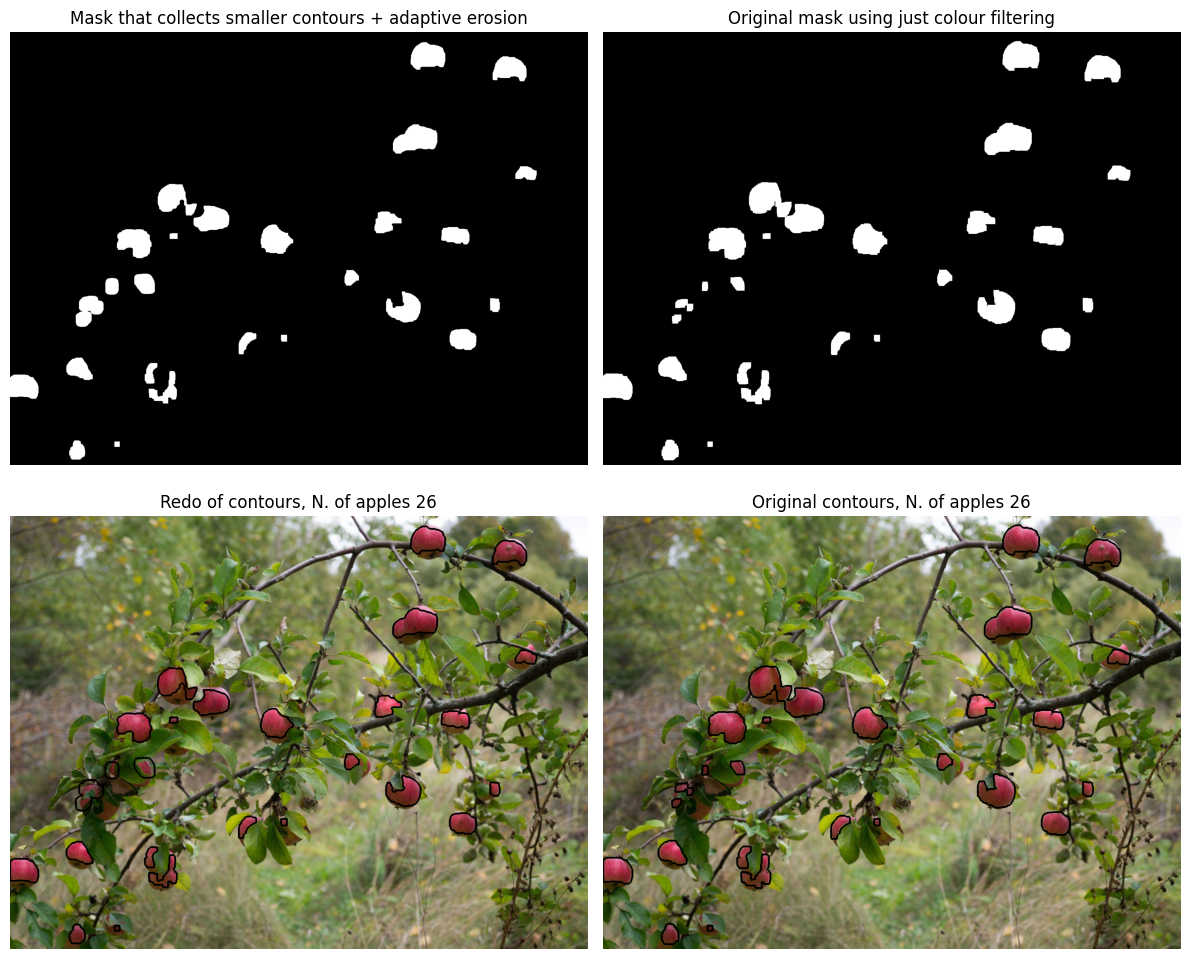

In [38]:
# Task 1 (redone)

cnts_2 = cv2.findContours(
    apple_mask_2.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

cnts_2 = imutils.grab_contours(cnts_2)

output_2 = image.copy()

for c in cnts_2:
    cv2.drawContours(output_2, [c], -1, (0, 0, 0), 3)


# Plot everything in a 2x2 layout
plt.figure(figsize=(12, 10))

# Top left: new mask
plt.subplot(2, 2, 1)
plt.imshow(apple_mask_2, cmap='gray')
plt.title("Mask that collects smaller contours + adaptive erosion")
plt.axis("off")

# Top right: original mask
plt.subplot(2, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Original mask using just colour filtering")
plt.axis("off")

# Bottom left: original image + contours from apple_mask_2
plt.subplot(2, 2, 3)
plt.imshow(output_2)
plt.title(f"Redo of contours, N. of apples {len(cnts_2)}")
plt.axis("off")

# Bottom right: original image + contours from original mask
plt.subplot(2, 2, 4)

cnts = cv2.findContours(
    mask.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

cnts = imutils.grab_contours(cnts)

output = image.copy()

for c in cnts:
    cv2.drawContours(output, [c], -1, (0, 0, 0), 3)

plt.imshow(output)
plt.title(f"Original contours, N. of apples {original_cnt_count}")
plt.axis("off")

plt.tight_layout()
plt.show()

Funny enough we get the same number of apples as before, but we can see the accuracy is much better. Before the apples in the blue square below were falsy counted as one apple, but they are in fact two, and the contours in the pink square were counted as two apples, even though they are only one. This is also why we end at the same number (26), since two contours have been collected as one, and one contour has been split in two. However the contours and the counting now more closely follow the actual apples.

This new version has numerical parameters they are obviously over-fitted to this specific image, but with hundreds of images of apple branches we are confident we could find parameters suitable for a substantial improvement in accuracy compared to the simpler algorithm first implemented.

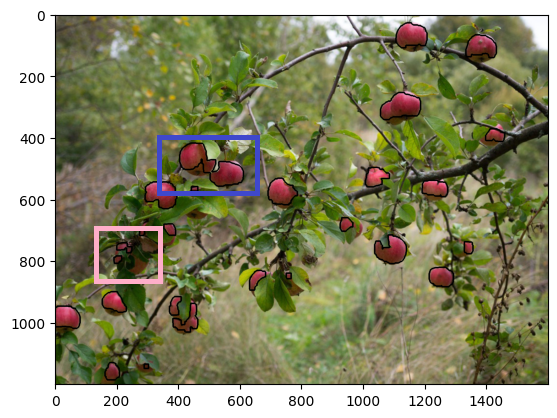

The image above is the old and wrong set of contours. Mistakes fixed by the more complex algorithm are highlighted in the coloured squares.

# Task 3

We chose a specific item designed after contour drawing, and we change its color to blue.

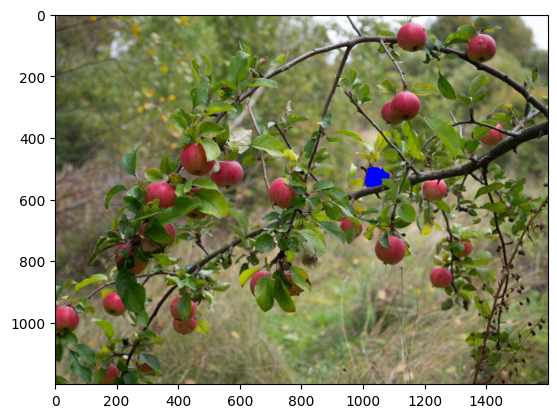

In [39]:
#Task 3
filled = image.copy()
cv2.drawContours(filled, [cnts[20]], -1, (0, 0, 255), -1)
plt.imshow(filled)

Experiment 1 applies blurring first so the background is considered as noise. The background gets defocused so we mostly keep the leaved in the tree that is closer to the camera. Then we apply a green mask filtering to keep the greenish colors of the leaves.  

(-0.5, 1599.5, 1199.5, -0.5)

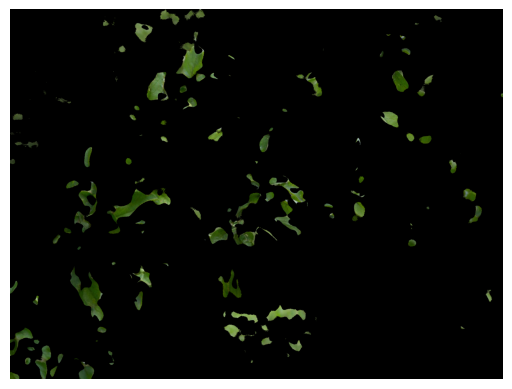

In [40]:
#Task 4

# Experiment 1

blurred = cv2.GaussianBlur(image, (45, 45), 0)
plt.imshow(blurred)
hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)

# define green color range
lower_green = np.array([41, 100, 60])
upper_green = np.array([90, 255, 255])

green_mask = cv2.inRange(hsv, lower_green, upper_green)
green_image = cv2.bitwise_and(image, image, mask=green_mask)

plt.imshow(green_image)
plt.axis("off")


Experiment 2 does not apply blurring like before. It only applies the green mask filtering. In that case, the shape of the leaves is better depicted but there is more backround noise that hasn't been reduced.

(-0.5, 1599.5, 1199.5, -0.5)

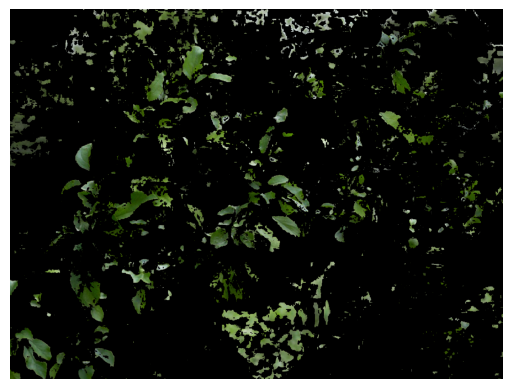

In [41]:
# Experiment 2

hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# define green color range
lower_green = np.array([41, 10, 60])
upper_green = np.array([90, 255, 255])

green_mask = cv2.inRange(hsv, lower_green, upper_green)
green_image = cv2.bitwise_and(image, image, mask=green_mask)

plt.imshow(green_image)
plt.axis("off")

# Weekly project part 2
1) Remove the greenscreen and replace the background in "itssp.png".
2) Can you improve the edge with eroding/dilating?


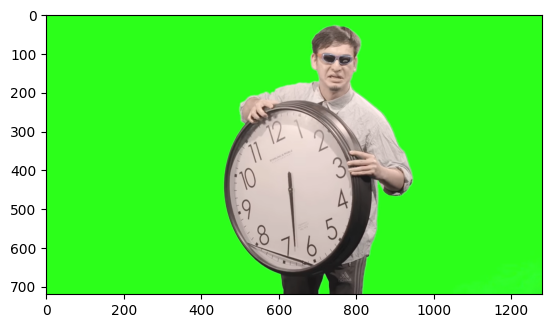

In [42]:
# Task 1
path = "ittsp.png"
bgr_img = cv2.imread(path)
b,g,r = cv2.split(bgr_img)
image = cv2.merge([r,g,b])
plt.imshow(image)

We apply a green mask filtering to identify the green area of the image. The detected green area is then replaced with appletree.jpg as the new background. After that, erosion and dilation are applied to experiment if the edges are modified in that case.

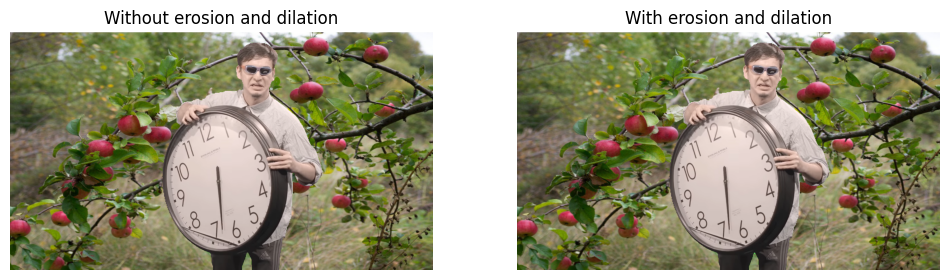

In [43]:
# RGB image -> HSV
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV) 

lower_green = np.array([25, 40, 60])
upper_green = np.array([90, 255, 255])
green_mask = cv2.inRange(hsv, lower_green, upper_green)

# appletree.jpg will be used as a replacement 
background = cv2.imread("appletree.jpg")
background = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)
background = cv2.resize(background, (image.shape[1], image.shape[0]))

final_image_original = np.where(green_mask[:, :, None] == 255, background, image)
mask = green_mask.copy()
kernel = np.ones((3, 3), np.uint8)
mask = cv2.erode(mask, kernel, iterations=3)
mask = cv2.dilate(mask, kernel, iterations=3)

final_image_processed = np.where(mask[:, :, None] == 255, background, image)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(final_image_original)
plt.title("Without erosion and dilation")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final_image_processed)
plt.title("With erosion and dilation")
plt.axis("off")

plt.show()

After erosion and dilation, no change was observed in the edges of the central figure. That is because the combination of erosion and dilation is used to erase small objects or holes, and not for sharpening big objects like this one.